### Dataset Description (Edgar Anderson's Iris Data)

This famous (Fisher's or Anderson's) iris data set gives the measurements in centimeters of the variables sepal length and width and petal length and width, respectively, for 50 flowers from each of 3 species of iris. The species are Iris setosa, versicolor, and virginica. Iris is a data frame with 150 cases (rows) and 5 variables (columns) named Sepal.Length, Sepal.Width, Petal.Length, Petal.Width, and Species.

In [5]:
library(datasets)
data(iris)
head(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


In [8]:
summary(iris)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

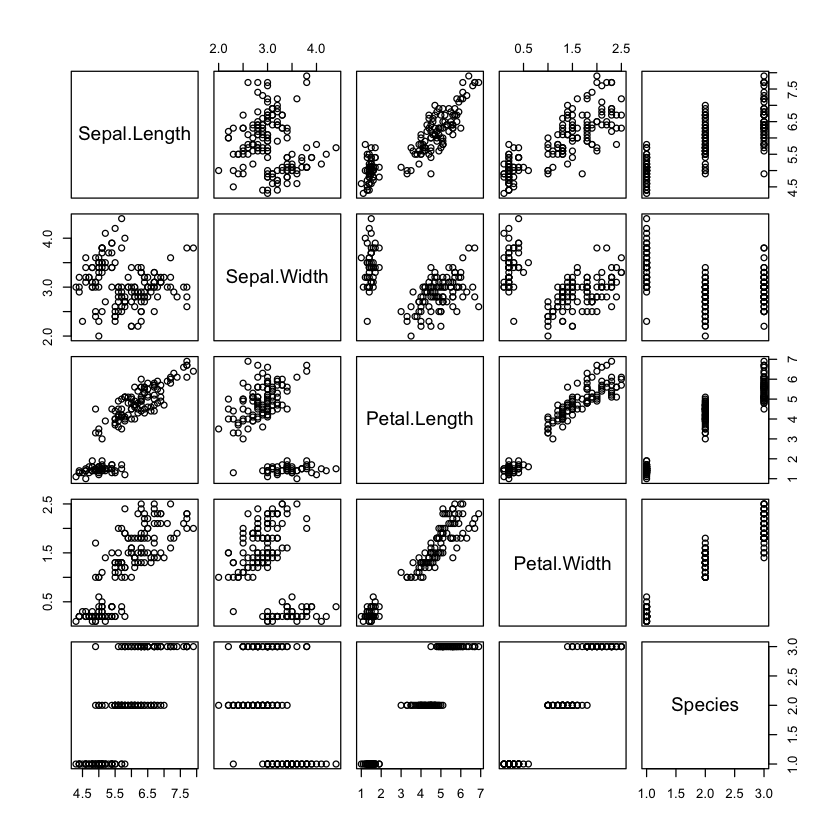

In [11]:
pairs(iris)

In [13]:
#?pairs

**1. Plot a scatter plot between sepal length and petal length and colour each point based on the species of the flower? What can you infer?**

In [2]:
library(ggplot2)

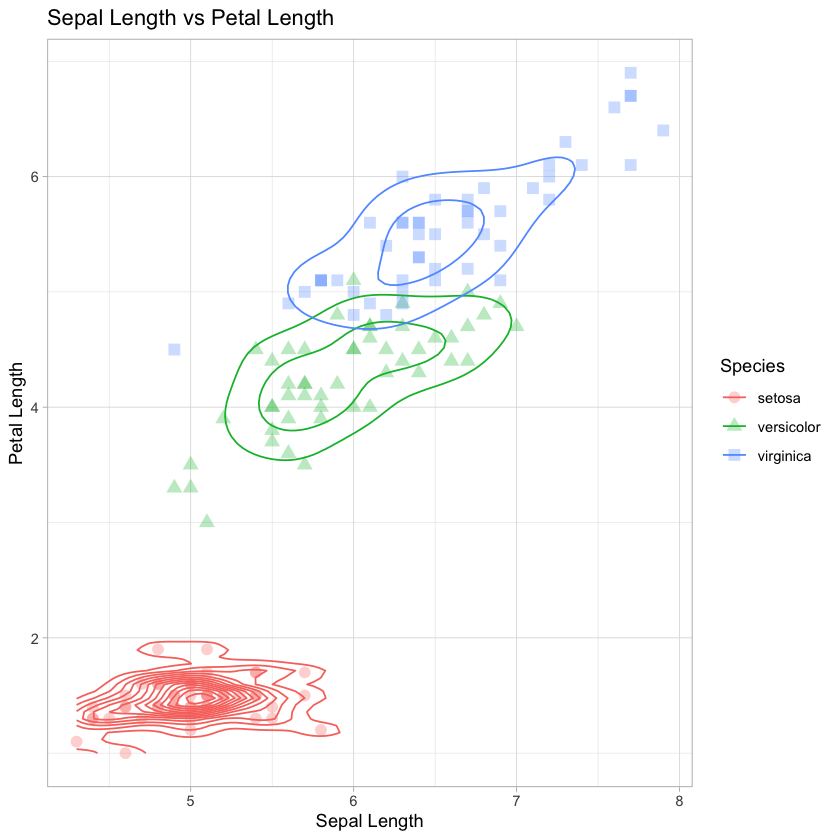

geom_density_2d {ggplot2},R Documentation
mapping,"Set of aesthetic mappings created by aes() or aes_(). If specified and inherit.aes = TRUE (the default), it is combined with the default mapping at the top level of the plot. You must supply mapping if there is no plot mapping."
data,"The data to be displayed in this layer. There are three options: If NULL, the default, the data is inherited from the plot data as specified in the call to ggplot(). A data.frame, or other object, will override the plot data. All objects will be fortified to produce a data frame. See fortify() for which variables will be created. A function will be called with a single argument, the plot data. The return value must be a data.frame, and will be used as the layer data. A function can be created from a formula (e.g. ~ head(.x, 10))."
position,"Position adjustment, either as a string, or the result of a call to a position adjustment function."
...,"Arguments passed on to geom_contour binsNumber of contour bins. Overridden by binwidth. binwidthThe width of the contour bins. Overridden by breaks. breaksNumeric vector to set the contour breaks. Overrides binwidth and bins. By default, this is a vector of length ten with pretty() breaks."
contour_var,"Character string identifying the variable to contour by. Can be one of ""density"", ""ndensity"", or ""count"". See the section on computed variables for details."
lineend,"Line end style (round, butt, square)."
linejoin,"Line join style (round, mitre, bevel)."
linemitre,Line mitre limit (number greater than 1).
na.rm,"If FALSE, the default, missing values are removed with a warning. If TRUE, missing values are silently removed."
show.legend,"logical. Should this layer be included in the legends? NA, the default, includes if any aesthetics are mapped. FALSE never includes, and TRUE always includes. It can also be a named logical vector to finely select the aesthetics to display."


In [27]:
ggplot(data = iris, aes(x = Sepal.Length, y = Petal.Length))+
  xlab("Sepal Length")+
  ylab("Petal Length") +
  geom_point(aes(color = Species,
                 shape = Species),
             alpha = 0.3,
             size = 3)+
  ggtitle("Sepal Length vs Petal Length")+
  stat_density2d(aes(x = Sepal.Length, 
                     y = Petal.Length, 
                     group = Species, 
                     color = Species),
                  bins = 15,
                  linejoin = "round",
                )+
  theme_light()
  #geom_smooth(method='lm')
?stat_density2d

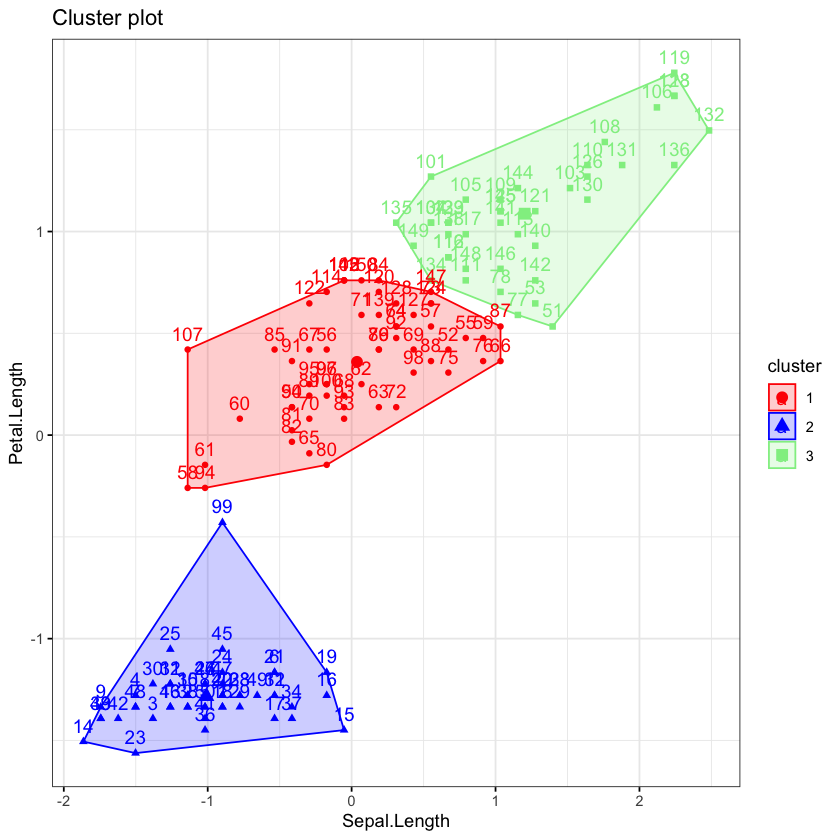

In [73]:
iris_kmeans_data <- subset(iris, select=c(Sepal.Length, Petal.Length))
iris_kmeans <- kmeans(iris_kmeans_data,3)
#iris_kmeans_data
# https://www.datanovia.com/en/blog/k-means-clustering-visualization-in-r-step-by-step-guide/
#install.packages("factoextra")
library(factoextra)
fviz_cluster(iris_kmeans, data = iris_kmeans_data,
             palette = c("red", "blue","lightgreen"),
             ellipse.type = "convex", 
             ggtheme = theme_bw()
             )

In [ ]:
ggscatter(
  iris_kmeans, x = "Dim.1", y = "Dim.2", 
  color = "cluster", palette = "npg", ellipse = TRUE, ellipse.type = "convex",
  shape = "Species", size = 1.5,  legend = "right", ggtheme = theme_bw(),
  xlab = paste0("Dim 1 (", variance.percent[1], "% )" ),
  ylab = paste0("Dim 2 (", variance.percent[2], "% )" )
)

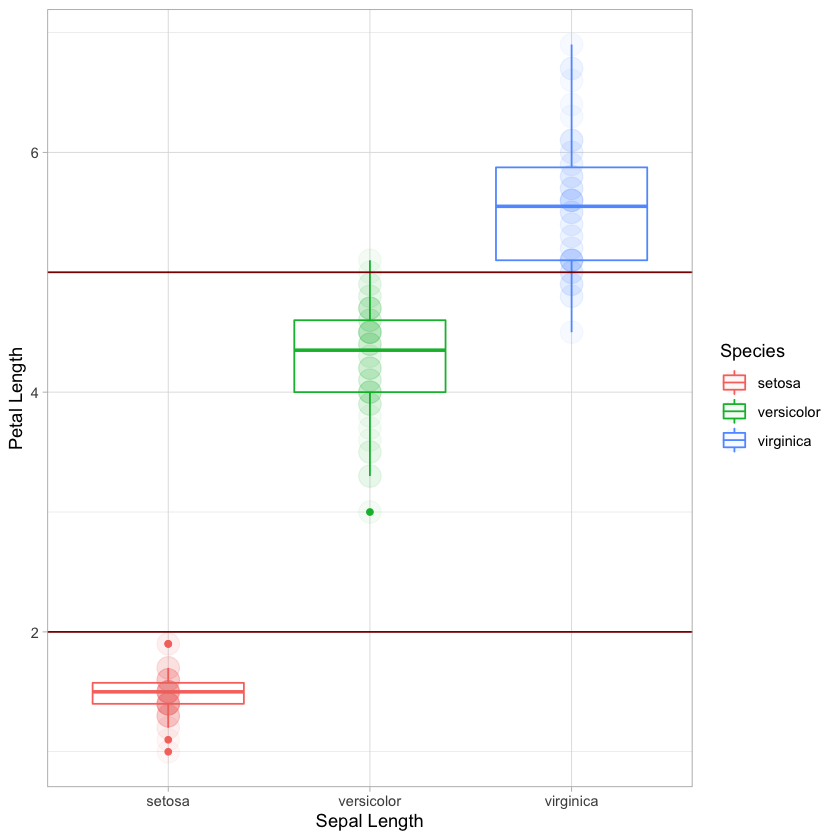

In [33]:
ggplot(data = iris, aes(x = Species, y = Petal.Length, colours=Species))+ 
        xlab("Sepal Length")+
        ylab("Petal Length") +
        geom_boxplot(aes(color = Species))+
        geom_point(aes(color = Species),alpha=0.05,size=6)+
        geom_hline(yintercept = 5, col="darkred")+
        geom_hline(yintercept = 2, col="darkred")+
        theme_light()
#?geom_jitter

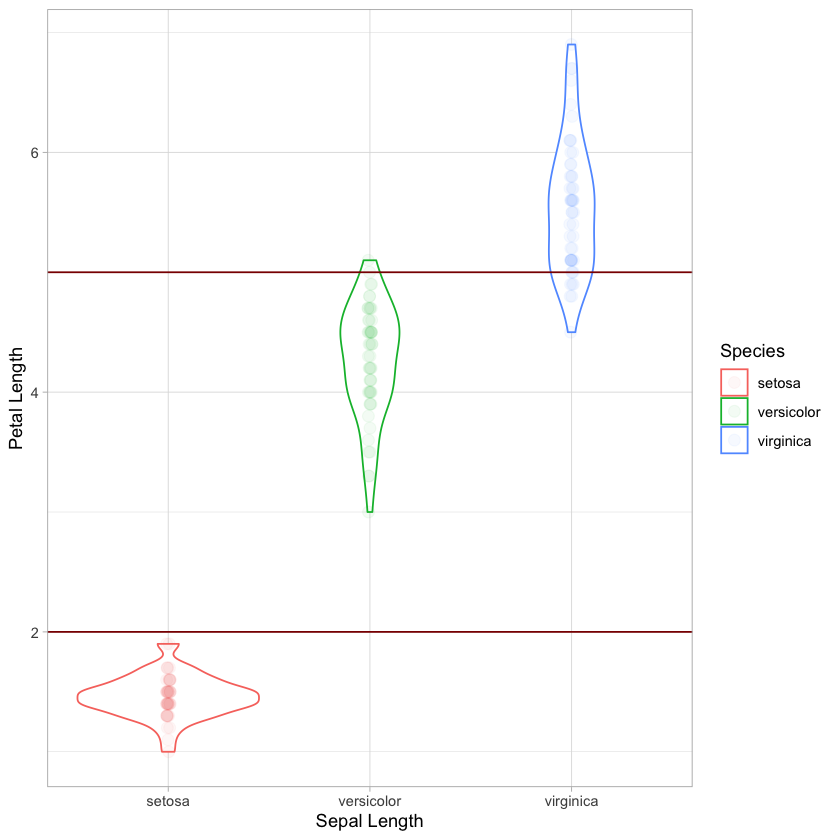

In [9]:
ggplot(data = iris, aes(x = Species, y = Petal.Length, colours=Species))+ 
        xlab("Sepal Length")+
        ylab("Petal Length") +
        geom_violin(aes(color = Species), trim=TRUE) + 
        geom_jitter(aes(color = Species),alpha=0.05, height = 0, width = 0.01, size=3)+
        geom_hline(yintercept = 5, col="darkred")+
        geom_hline(yintercept = 2, col="darkred")+
        theme_light()
#?geom_violin

**2. Plot histograms of petal length and petal width? Do they look similar? Why do you think so?**

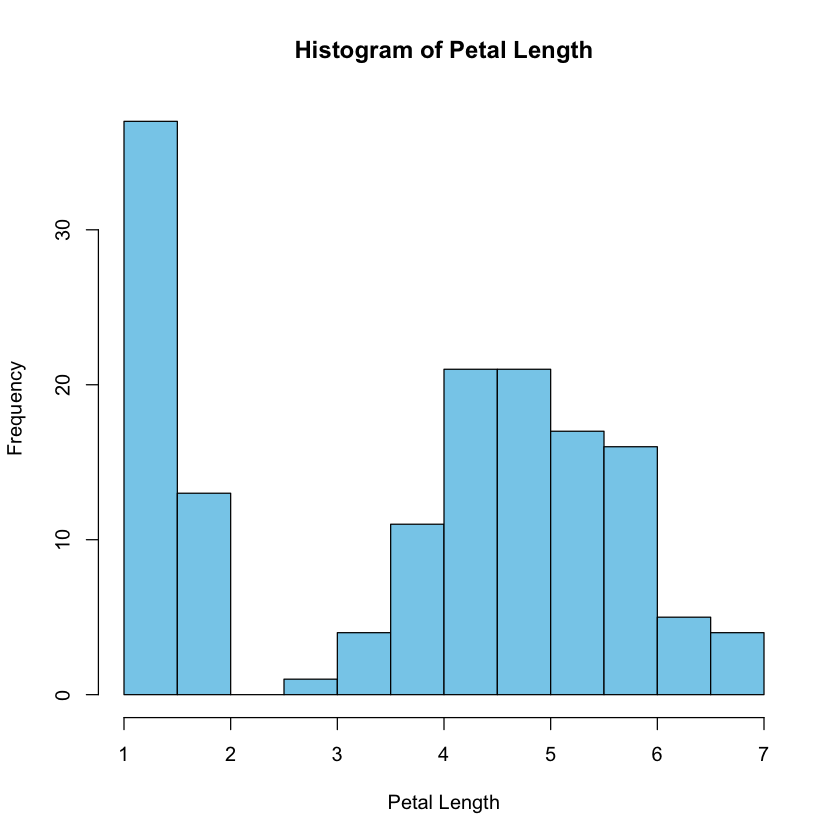

In [157]:
h1 <- hist(iris$Petal.Length, 
           xlab="Petal Length", 
           main = "Histogram of Petal Length", 
           breaks=12, 
           col= "skyblue")
#?hist

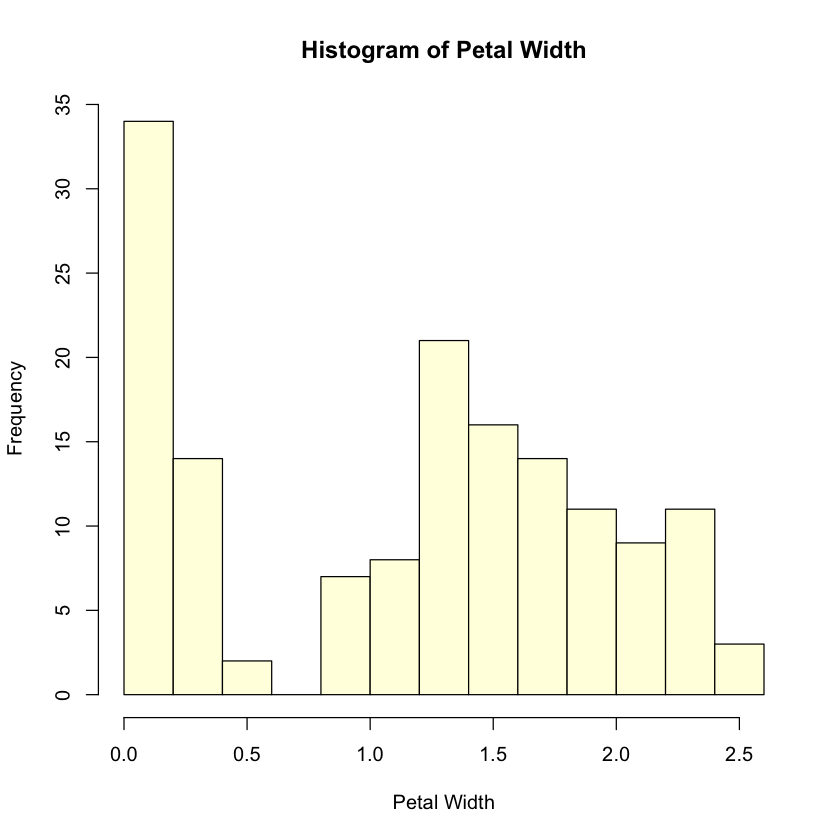

In [229]:
h2 <- hist(iris$Petal.Width, 
           xlab="Petal Width", 
           main = "Histogram of Petal Width", 
           breaks=12,
           col = "lightyellow")
#?hist
h2 + 

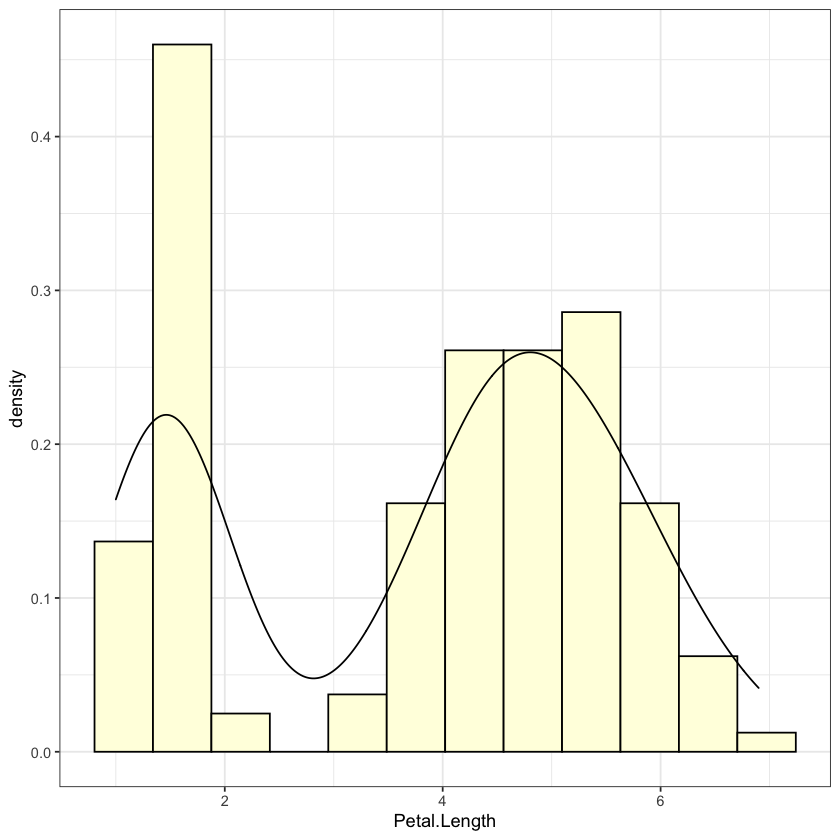

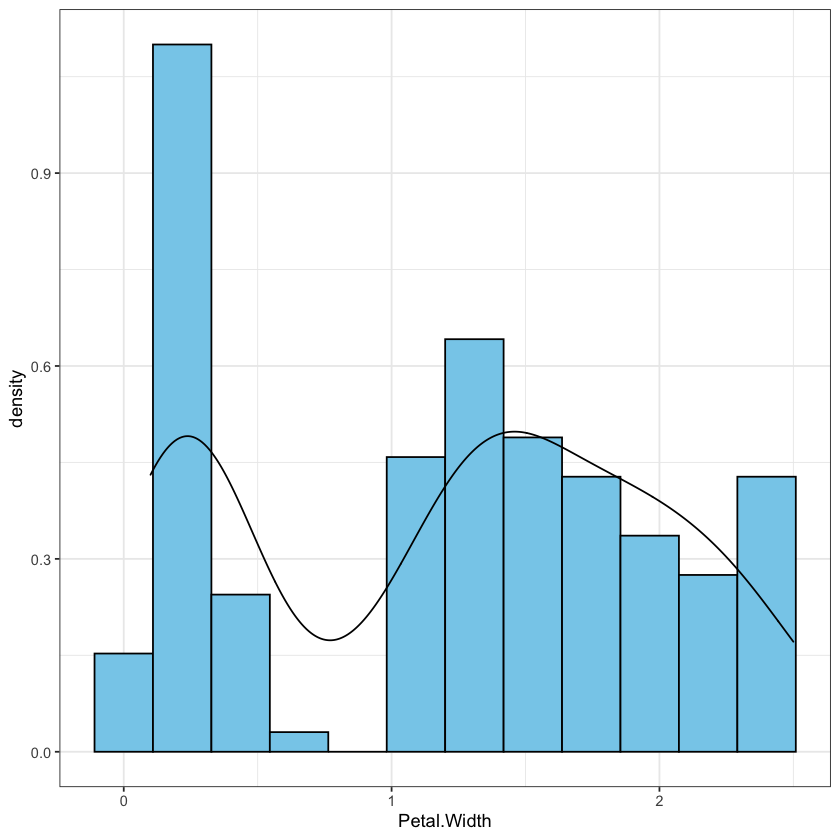

In [65]:
ggplot(iris, aes(x=Petal.Length)) + 
geom_histogram(aes(y=..density..),bins=12, fill = "lightyellow", colour="black") + 
geom_density()+
theme_bw()

ggplot(iris, aes(x=Petal.Width)) + 
geom_histogram(aes(y=..density..),bins=12, fill = "skyblue", colour="black") + 
geom_density()+
theme_bw()

`geom_smooth()` using formula 'y ~ x'



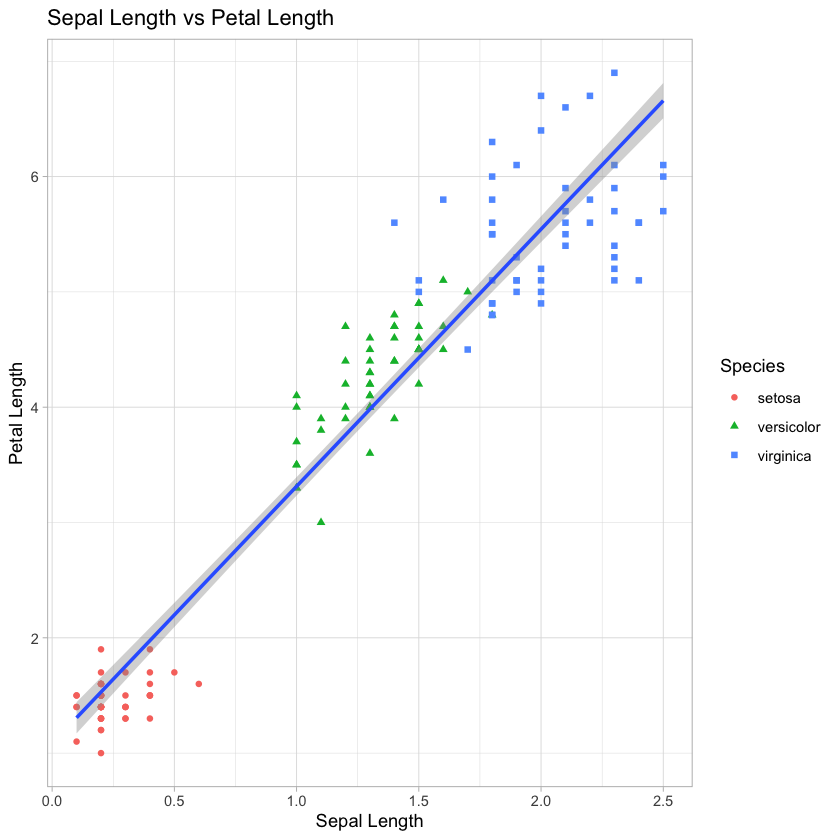

In [230]:
ggplot(data = iris, aes(x = Petal.Width, y = Petal.Length))+
  xlab("Sepal Length")+
  ylab("Petal Length") +
  geom_point(aes(color = Species,shape=Species))+
  ggtitle("Sepal Length vs Petal Length")+theme_light()+geom_smooth(method='lm')

In [126]:
cor.test(iris$Petal.Width, iris$Petal.Length, method="spearman")
#shapiro.test(iris$Petal.Width)
#shapiro.test(iris$Petal.Length)

Warning message in cor.test.default(iris$Petal.Width, iris$Petal.Length, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  iris$Petal.Width and iris$Petal.Length
S = 35061, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.9376668 


In [121]:
# prcomp(subset(iris, select=c(Sepal.Length, Petal.Length, Species)))

**3. Plot a boxplot of petal lengths for various species of the flowers? Do you find the same pattern from petal width**

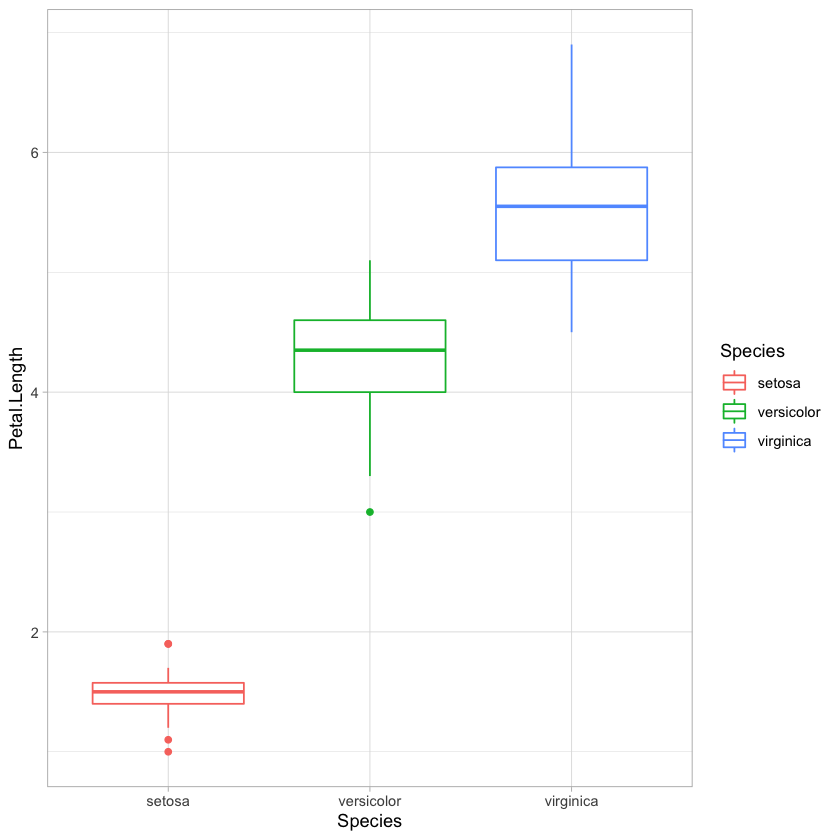

In [162]:
ggplot(iris, aes(x=Species, y=Petal.Length)) + 
  geom_boxplot(aes(col=Species))+theme_light()

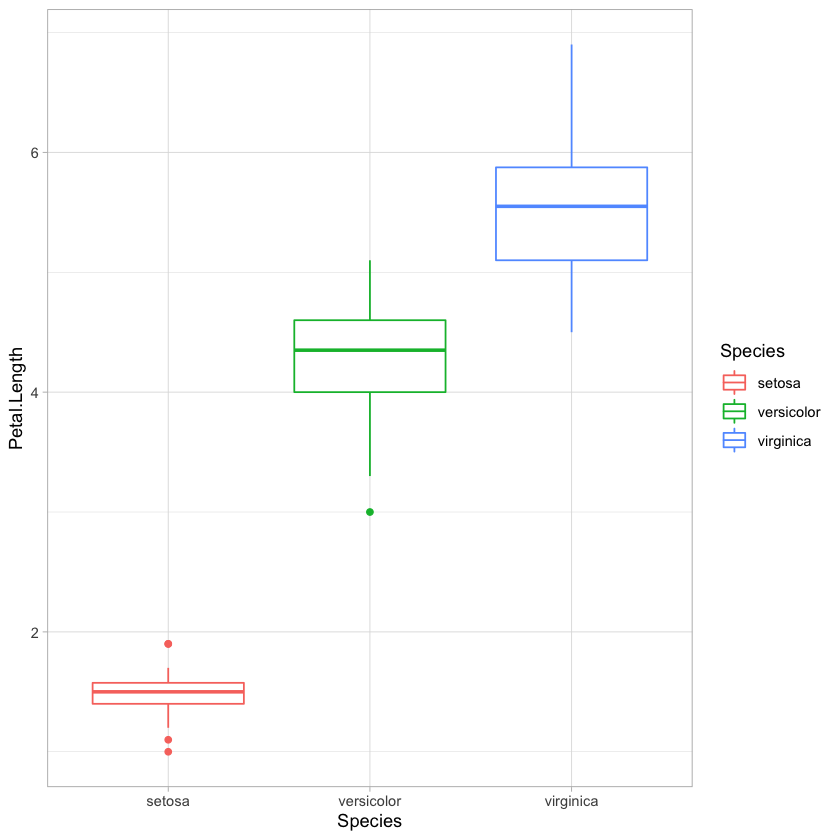

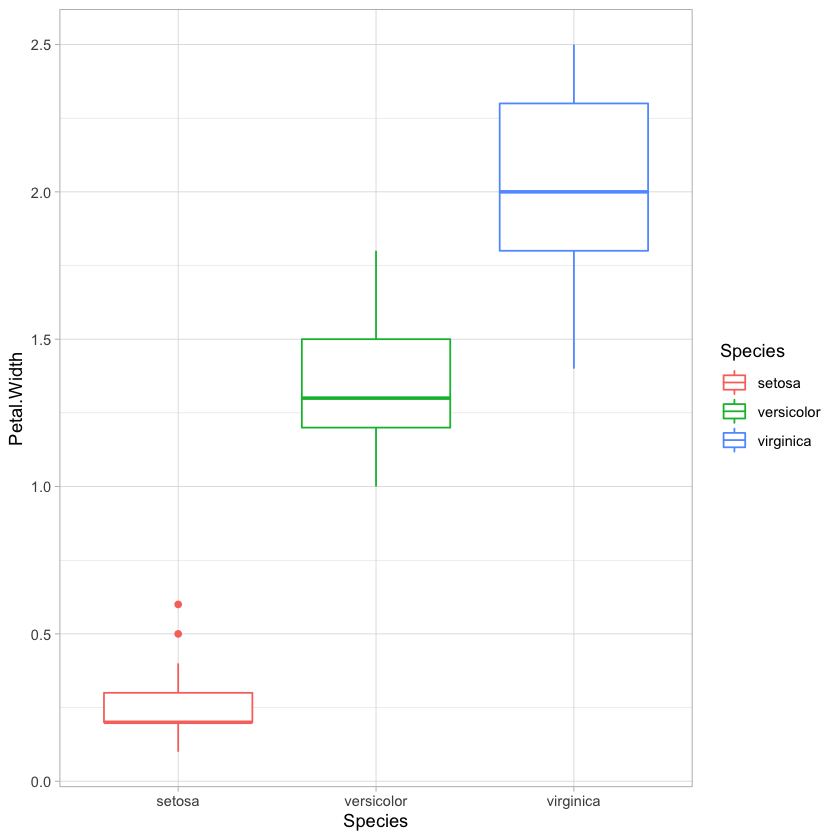

In [127]:
ggplot(iris, aes(x=Species, y=Petal.Length)) + 
  geom_boxplot(aes(col=Species))+theme_light()
ggplot(iris, aes(x=Species, y=Petal.Width)) + 
  geom_boxplot(aes(col=Species))+theme_light()

**4. Create a dotplot representing mean petal length for various species of flower?**

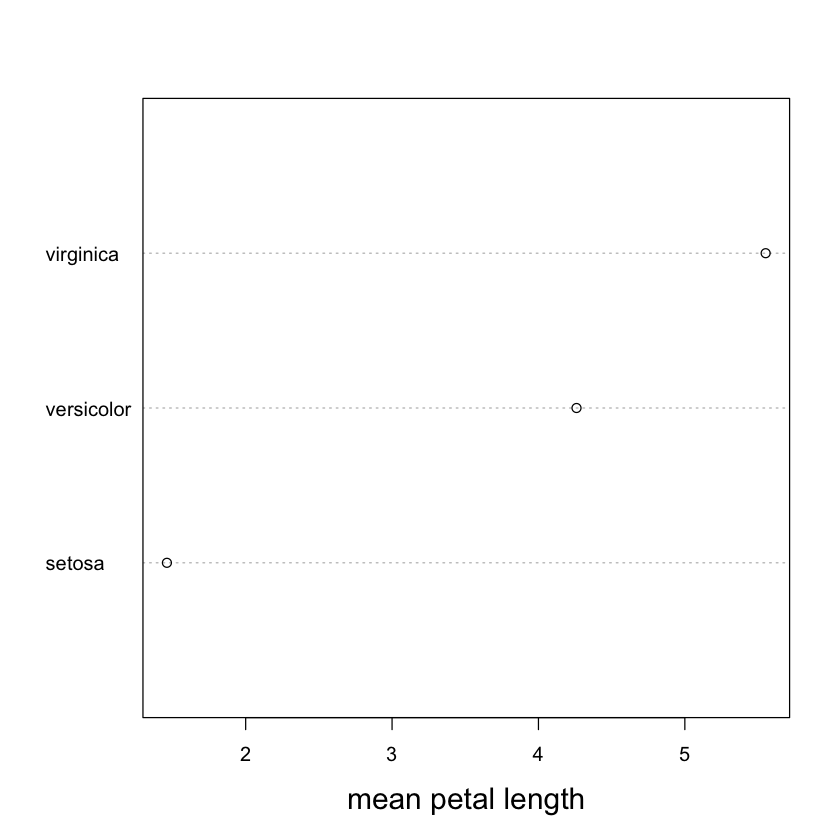

In [119]:
# ggplot(iris, aes(x=Species, y=Petal.Length)) + geom_dotplot()
#dotchart(iris$Petal.Length, labels = row.names(iris),
#         cex = 0.6, xlab = "mpg")
#dotchart(iris$Petal.Length, labels = row.names(iris), cex = 0.6, xlab = "mpg")
#?aggregate
means <- aggregate(iris$Petal.Length, list(iris$Species), mean)
rownames(means) <- means[,1]
# means
dotchart(means$"x", labels = rownames(means), xlab="mean petal length", 
         cex.lab=1.5)

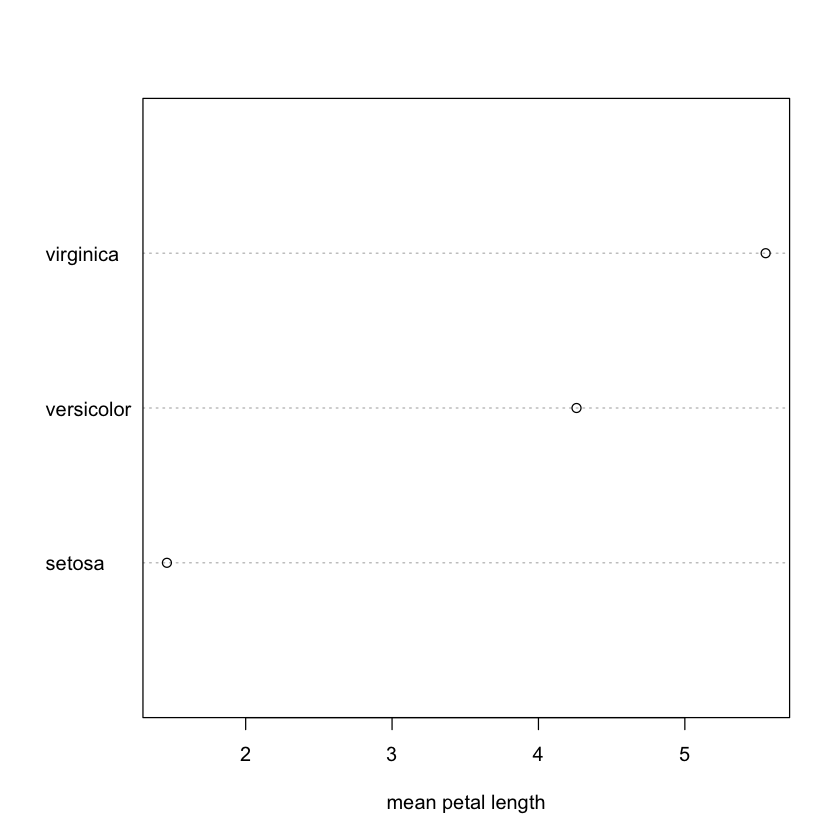

In [11]:
means <- aggregate( Petal.Length ~ Species, iris, mean )
dotchart(means$Petal.Length, 
         labels = means$Species,
         xlab = " mean petal length ")
#?dotchart

**5. Go to Quick-R (https://www.statmethods.net/). Check out some of the graphs there. Select an appropriate graph and apply it on iris. What do you see?**

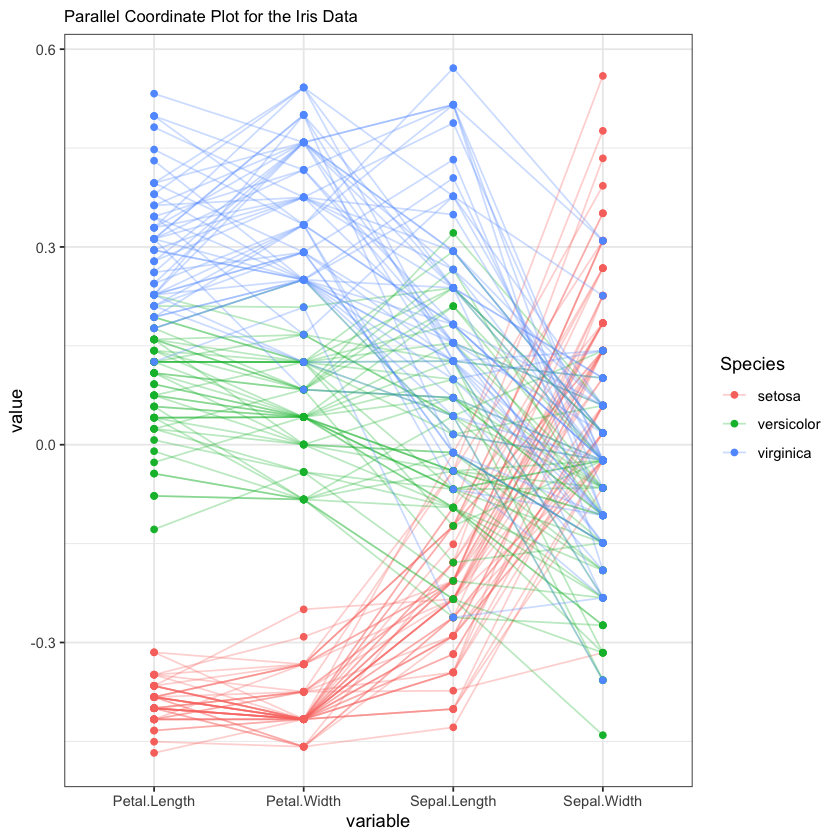

In [165]:
# https://www.r-graph-gallery.com/93-parrallel-plot.html#reorder
library(GGally)
 
ggparcoord(iris,
    columns = 1:4, groupColumn = 5, order = "anyClass",
    showPoints = TRUE, 
    title = "Parallel Coordinate Plot for the Iris Data",
    alphaLines = 0.3,
    scale= "center"
    ) + 
  theme_bw()+
  theme(
    plot.title = element_text(size=10)
  )

In [181]:
library(GGally)
ggcorr(iris, method = c("everything", "spearman")) 

Warning message in ggcorr(iris, method = c("everything", "spearman")):
“data in column(s) 'Species' are not numeric and were ignored”


ERROR: Error in facet_grid(data = iris, cols = vars(Species)): unused argument (data = iris)
